In [1]:
import copy
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

In [13]:
from collections import namedtuple, deque
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
class actor(nn.Module):
    '''
    The actor class
    '''
    def __init__(self, state_dim, action_dim, max_action):
        '''
        input(s): dimensions of state and action, and the max action
        '''
        super(actor, self).__init__()
        
        self.set_params()
        self.max_action = max_action
        
        self.set_up_layers()
    
    def set_up_layers(self):
        '''
        make structure for the actor network
        '''
        self.l1 = nn.Linear(state_dim, self.dim_1)
        self.l2 = nn.Linear(self.dim_1, self.dim_2)
        self.l3 = nn.Linear(self.dim_2, action_dim)
    
    def forward(self, state):
        '''
        forward propagate the network
        input(s): state
        output(s): result of the actor network
        '''
        out = F.relu(self.l1(state))
        out = F.relu(self.l2(out))
        return self.max_action * torch.tanh(self.l3(out))
        
    
    def set_params(self, dim_1 = 400, dim_2 = 300):
        '''
        set the parameters for the number of neurons
        input(s): dims for neuron layers
        '''
        self.dim_1 = dim_1
        self.dim_2 = dim_2

In [4]:
class critic(nn.Module):
    '''
    critic class
    '''
    def __init__(self, state_dim, action_dim):
        '''
        input(s): dimensions of state and action
        '''
        super(critic, self).__init__()
        
        self.set_params()
        
        self.set_up_layers()
    
    def set_up_layers(self):
        '''
        make structure for the actor network
        '''
        self.l1 = nn.Linear(state_dim + action_dim, self.dim_1)
        self.l2 = nn.Linear(self.dim_1, self.dim_2)
        self.l3 = nn.Linear(self.dim_2, 1)
    
    def forward(self, state, action):
        '''
        forward propagate the network
        input(s): state and action
        output(s): result of the critic network
        '''
        state_action = torch.cat([state, action], dim = 1)
        out = F.relu(self.l1(state_action))
        out = F.relu(self.l2(out))
        return self.l3(out)
        
    def set_params(self, dim_1 = 400, dim_2 = 300):
        '''
        set the parameters for the number of neurons
        input(s): dims for neuron layers
        '''
        self.dim_1 = dim_1
        self.dim_2 = dim_2

In [7]:
class replay_Buffer():
    '''
    buffer for storing previous experiences (s, a, r, s_next)
    '''
    def __init__(self, action_size, buffer_size, batch_size):
        self.action_size = action_size
        self.memory = deque(maxlen = buffer_size)
        self.batch_size = batch_size
        self.experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", 'done'])
        
    def add(self, state, action, reward, next_state, done):
        '''
        add state, action, reward, next_state, done to buffer
        input(s): state, action, reward, next_state, done
        '''
        self.memory.append(self.experience(state, action, reward, next_state, done))
    
    def sample(self):
        '''
        Sample a set of experiences from memory
        '''
        states = torch.from_numpy(np.vstack([e.state for e in experiences if e is not None])).float().to(device)
        actions = torch.from_numpy(np.vstack([e.action for e in experiences if e is not None])).float().to(device)
        rewards = torch.from_numpy(np.vstack([e.reward for e in experiences if e is not None])).float().to(device)
        next_states = torch.from_numpy(np.vstack([e.next_state for e in experiences if e is not None])).float().to(device)
        dones = torch.from_numpy(np.vstack([e.done for e in experiences if e is not None]).astype(np.uint8)).float().to(device)
        
    def __len__(self):
        '''
        return the current size of memory
        '''
        return len(self.memory)

In [1]:
24 % 12

0

In [2]:
month = 20

In [3]:
year = int(month/ 12) 

In [4]:
year

1

In [21]:
b = 10000

In [22]:
month = 0
all_bs = []

In [23]:
while b > 0:
    b = b - 500
    b = b*0.005 +b
    all_bs.append(b)
    month+=1

In [24]:
month

22

In [25]:
all_bs


[9547.5,
 9092.7375,
 8635.701187499999,
 8176.379693437499,
 7714.761591904686,
 7250.835399864209,
 6784.58957686353,
 6316.012524747848,
 5845.092587371588,
 5371.818050308446,
 4896.177140559988,
 4418.158026262789,
 3937.7488163941025,
 3454.937560476073,
 2969.7122482784534,
 2482.060809519846,
 1991.9711135674452,
 1499.4309691352823,
 1004.4281239809587,
 506.95026460086353,
 6.985015923867851,
 -495.4800589965128]

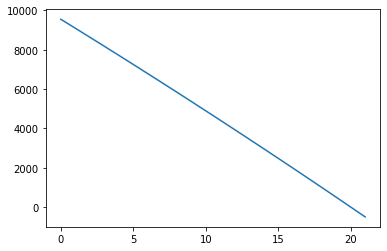

In [26]:
plt.plot(all_bs)
plt.show()